In [1]:
#
# This notebook provides examples of how to load and manipulate data distributed
# with the Lyman-alpha Tomography IMACS Survey (LATIS) data release v1.0.
#

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units

In [3]:
# Replace with the directory where you store the LATIS DR v1.0 data.
datadir = '../../dr/v1.0/'

# Utility functions

In [4]:
# Tools to convert between world coordinates (RA, Dec, redshift) and IGM map voxel
# coordinates (X, Y, Z).

In [5]:
from astropy.cosmology import Planck15 as cosmo
mapspan = {'D1': [65, 53], 'D4': [33, 47], 'D2': [93, 51]} # map transverse dimensions
ra0 = {'D1': 36.4749, 'D4': 334.0852, 'D2': 150.0606} # central coordinates
dec0 = {'D1': -4.3384, 'D4': -17.5797, 'D2': 2.2026}

In [6]:
# Input:  World coordinates RA (deg), Dec (deg), redshift as floats or numpy arrays.
#         field = 'D1', 'D2', or 'D4'
# Output: Tuple (x,y,z) of map coordinates. Integer coordinates refer to voxel edges.
# Note that there is no guarantee that the output coordinates actually lie within
# the volume of the map.
def tomapcoords(RA, Dec, redshift, field=None):
    assert field in ['D1','D2','D4']
    degtocMpch = cosmo.angular_diameter_distance(redshift).to(units.Mpc).value * (1 + redshift) * cosmo.h # cMpc/h per radian
    degtocMpch /= 180./np.pi # cMpc/h per deg
    x = -(RA - ra0[field]) * np.cos(np.radians(dec0[field])) * degtocMpch + mapspan[field][0] / 2.0
    y = (Dec - dec0[field]) * degtocMpch + mapspan[field][1] / 2.0
    z = cosmo.comoving_distance(redshift).to(units.Mpc).value * cosmo.h # cMpc/h
    z -= cosmo.comoving_distance(2.2).to(units.Mpc).value * cosmo.h
    return (x, y, z)

In [7]:
# Input:  x, y, z map coordinates as floats or numpy arrays; integers are voxel edges.
#         field = 'D1', 'D2', 'or 'D4'
# Output: Tuple (RA, Dec, z) of world coordinates.
# Note there is no check that the input coordinates lie within the map volume.
def frommapcoords(x, y, z, field=None):
    assert field in ['D1','D2','D4'] 
    redshiftarr = np.linspace(1.5, 3.5, 200)
    zcoords = (cosmo.comoving_distance(redshiftarr) - cosmo.comoving_distance(2.20)).to(units.Mpc).value * cosmo.h
    redshift = np.interp(z, zcoords, redshiftarr)
    degtocMpch = cosmo.angular_diameter_distance(redshift).to(units.Mpc).value * (1 + redshift) * cosmo.h # cMpc/h per rad
    degtocMpch /= 180./np.pi # cMpc/h per deg
    RA = -(x - mapspan[field][0] / 2.0) / degtocMpch / np.cos(np.radians(dec0[field])) + ra0[field]
    Dec = (y - mapspan[field][1] / 2.0) / degtocMpch + dec0[field]
    return (RA, Dec, redshift)

# Load LATIS data

In [8]:
from astropy.io import fits
# Load redshift catalog and database of 1D spectra
specmeas = Table.read(datadir+'latis_zspec.fits')
spectra = Table.read(datadir+'latis_spectra.fits')
specmeas.add_index('name') # allow access by target name, e.g., specmeas.loc['D1-181266']['z']
spectra.add_index('name')
# Load maps of delta_F / sigma_map with axies order x,y,z (hence .T)
igmmaps = {f: fits.open(datadir+'%s_map.fits' % f)['DELTA_F_NORM'].data.T for f in ['D1','D2','D4']}

# Plot redshift distributions per field

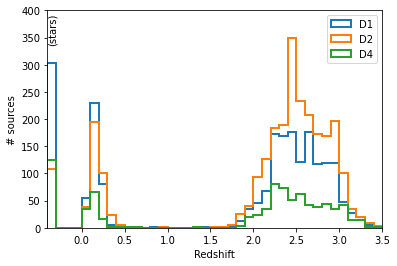

In [9]:
def zdist():
    bins = np.linspace(-0.4, 3.6, 41)
    
    for field in ['D1','D2','D4']:
        # Select redshifts from the field being considering.
        z = specmeas['z'][specmeas['field'] == field]
        # Put the stars at z = -0.3 instead of exactly 0, for clearer 
        # separation from the galaxies.
        z[z==0] = -0.3
        plt.hist(z, bins=bins, histtype='step', label=field, lw=2)
        
    plt.legend()
    plt.xlim([-0.4,3.5])
    plt.ylim([0,400])
    plt.text(-0.4, 340, '(stars)', rotation=90)
    plt.xlabel('Redshift')
    plt.ylabel('# sources')
zdist()

# Plot IGM map slice and overlay LATIS galaxies

In [10]:
# Set up the color bar used in some of the LATIS visualizations
from matplotlib import colors, cm
class NullNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        colors.Normalize.__init__(self, vmin, vmax, clip)
    def __call__(self, value, clip=None):
        x, y = [self.vmin, 0.0, self.vmax], [0.0, 0.5, 1.0]
        return np.ma.masked_array(np.interp(value, x, y), mask=np.isnan(value))
import copy
cmap = copy.copy(cm.jet_r)
cmap.set_bad(color='white', alpha=1)

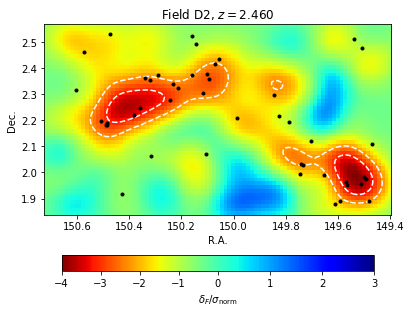

In [11]:
def plot_cross_section(field, redshift):
    plt.figure(figsize=(8,5))
    # Get the z voxel coordinate corresponding to the provided redshift.
    # (Note that RA, Dec are irrelevant to the redshift <-> zpix conversion.)
    zcoord = int(round(tomapcoords(0, 0, redshift, field=field)[2]))
    
    # Determine RA, Dec of the corners of the map at the specified redshift.
    LL = frommapcoords(0, 0, zcoord, field=field) # lower-left
    UR = frommapcoords(igmmaps[field].shape[0], igmmaps[field].shape[1], zcoord, field=field) # upper-right
    extent = (LL[0], UR[0], LL[1], UR[1])
    
    # Plot IGM transmission map with contours of -4, -3, -2
    ims = plt.imshow(igmmaps[field][:,:,zcoord].T, origin='lower', cmap=cmap,
                     norm=NullNormalize(vmin=-4, vmax=3), extent=extent, aspect='equal')
    plt.contour(igmmaps[field][:,:,zcoord].T, levels=[-4, -3, -2], colors='w',
                origin='lower', extent=extent)
    plt.colorbar(ims, location='bottom', label=r'$\delta_F / \sigma_{\rm norm}$', shrink=0.7)
    
    # Select galaxies within +- 500 km/s of the specified redshift within the specified field
    dv = (specmeas['z'] - redshift) / (1 + redshift) * 299792.
    w = (np.abs(dv) < 500) & (specmeas['field'] == field)
    plt.plot(specmeas['RA'][w], specmeas['Dec'][w], 'ko', ms=3)
    
    plt.xlabel('R.A.') ; plt.ylabel('Dec.')
    plt.title(r'Field %s, $z = %0.3f$' % (field,redshift))
    
plot_cross_section('D2', 2.46)

# Create a composite LBG spectrum

3835  galaxies in total


/export/data1/anewman/anaconda3/envs/nbodykit-env/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1218: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


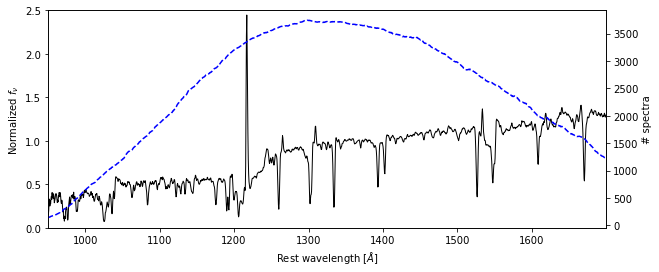

In [12]:
def composite_spectrum(subset):
    # subset = list of target names whose spectra we will average in the rest frame
    N = len(subset)
    lambda_rest = np.arange(750*2) * 0.5 + 950.0 # from 950-1700 A in 0.5 A pixels
    Nlam = len(lambda_rest)
    spec_to_avg = np.zeros((Nlam, N))
    for i, name in enumerate(subset):
        wave_obs = spectra.loc[name]['wave']
        flux_obs = spectra.loc[name]['flux']
        z = specmeas.loc[name]['z']
        # Interpolate spectra onto a common rest-frame grid. For rest-wavelengths
        # out of the observed range, set to NaN.
        spec_to_avg[:,i] = np.interp(lambda_rest, wave_obs / (1+z), flux_obs,
                                     left=np.nan, right=np.nan)
    # Normalize spectra to the median flux density from 1300-1500 A.
    # (Normalizing before averaging is a more sensible behavior when the data include
    #  masked pixels, as is the case here.)
    wnorm = (lambda_rest > 1300) & (lambda_rest < 1500)
    norm = np.nanmedian(spec_to_avg[wnorm, :], axis=0) # respect the mask by using nanmedian
    spec_to_avg /= norm
    # Average the normalized spectra, respecting the mask
    avg = np.nanmean(spec_to_avg, axis=1)
    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(lambda_rest, avg, 'k', lw=1)
    plt.xlim(lambda_rest[0], lambda_rest[-1])
    plt.ylabel(r'Normalized $f_{\nu}$')
    plt.xlabel(r'Rest wavelength [$\AA$]')
    plt.ylim([0,2.5]);
    
    # On the right axis, show the number of spectra entering the average at each pixel.
    # This varies strongly with wavelength due to the limited observed bandpass.
    Nspec = np.sum(~np.isnan(spec_to_avg), axis=1)
    plt.twinx()
    plt.plot(lambda_rest, Nspec, 'b--')
    plt.ylabel('# spectra')

# Select galaxies (not QSOs) at z > 2 that do not have the badredux flag set (which would
# indicate severely compromised data quality). Note the zspec catalog only includes
# high-confidence redshifts so no cut on zqual is needed. Compute and plot their
# average spectrum.

w = (specmeas['z'] > 2) & ~specmeas['isqso'] & ~specmeas['badredux']
print(np.count_nonzero(w), ' galaxies in total')
composite_spectrum(specmeas['name'][w])

# Compare delta_F distribution of maps to mocks

In [13]:
def deltaF_pdf(dFmap, **kwargs):
    bins = np.linspace(-0.35, 0.25, 100)
    # (Here we remove voxels near the map boundaries to suppress edge effects,
    #  although this is not necessary since the mocks suffer the same effects.)
    plt.hist(dFmap[4:-4,4:-4,4:-4].ravel(), bins=bins, histtype='step', **kwargs)
    plt.yscale('log')
    plt.xlabel(r'$\delta_F$')
    plt.ylabel('Number of voxels')
    plt.ylim([10,2e5])
    
def compare_pdfs(field):
    # Load the observed map of the requested field, not normalized by sigma_map.
    observed = fits.open(datadir+'%s_map_unnorm.fits' % field)['DELTA_F'].data
    # Plot the observed distribution of delta_F.
    deltaF_pdf(observed, color='k', lw=3)
    # Load 20 mock-observed maps in this field (of 100 available) and overlay their
    # delta_F_rec distributions.
    for i in range(20):
        mock = fits.open(datadir+'mocks/%s_%02d.fits' % (field, i))['DELTA_F_REC'].data
        deltaF_pdf(mock, color='k', alpha=0.2)
    plt.title(field)

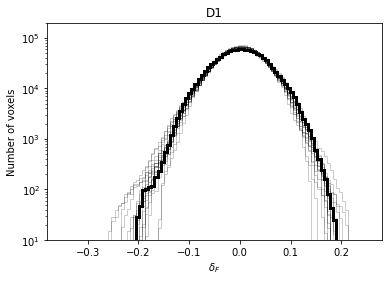

In [14]:
compare_pdfs('D1')